# PyTorch 환경 확인

In [2]:
import torch

print('PyTorch:', torch.__version__); 
print('CUDA 사용 가능:', torch.cuda.is_available()); 
print('GPU:', torch.cuda.get_device_name(0))

# ultralytics.checks()

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)

사용 장치: cuda


# MNIST Model

# 1. Torch Vision Dataset : MNIST

## 1.1.  MNIST Dataset 가져오기

In [7]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:16<00:00, 588kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 149kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.69MB/s]


## 1.2. 데이터 로더 

- batch_size=64 : 한 번에 64장씩 학습 
- shuffle=True : 학습 데이터 섞기, shuffle=False : 테스트는 순서 섞지 않아도 됨

In [8]:
# 5. Tensor 변환
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Sequential Model 기반

## 2.1. 모델 정의 (with 손실함수, Optimizer)
- nn.Sequential로 간결한 모델 표현 → 클래스 기반(IrisNet)과 대비되어 두 스타일 모두 경험 가능

In [15]:
model = nn.Sequential(
    nn.Flatten(),          # 28x28 이미지를 784칸으로 펼침
    nn.Linear(784, 128),   # 입력 784개 → 128개
    nn.ReLU(),             # 활성화 함수
    nn.Dropout(0.5),       # 일부를 끄면서 과적합 방지
    nn.Linear(128, 10)     # 10개 숫자(0~9) 출력
)

model = model.to(device)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
# class MnistNet(nn.Module) :
#     def __init__(self) : # 신경모델망 생성자
#         super().__init__()
#         self.fc1 = nn.Linear(28*28,256)   # 입력특성 4개
#         self.fc2 = nn.Linear(256,128)
#         self.fc3 = nn.Linear(128,10)   # 출력 클래스 3개
        
#     def forward(self, x) :  # 순방향 학습
#         x = self.fc1(x)
#         x = self.fc2(x)
#         x = self.fc3(x)
        
#         return x

In [16]:
# 8. 손실함수와 Optimaizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) # lr 학습률

## 2.2. Model 학습

In [17]:
# 9. 학습 Loop
num_epochs = 10
loss_history = []

for epoch in range(num_epochs) :
    
    model.train() # 학숩
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    epoch_loss = total_loss / len(train_loader) 
    loss_history.append(epoch_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], loss: {epoch_loss:.4f}")

Epoch [1/10], loss: 0.4545
Epoch [2/10], loss: 0.2472
Epoch [3/10], loss: 0.1994
Epoch [4/10], loss: 0.1753
Epoch [5/10], loss: 0.1580
Epoch [6/10], loss: 0.1437
Epoch [7/10], loss: 0.1369
Epoch [8/10], loss: 0.1280
Epoch [9/10], loss: 0.1240
Epoch [10/10], loss: 0.1191


## 2.3. 학습결과 평가

## 2.3. 학습결과 평가

In [18]:
# 10. 평가
model.eval()

correct = 0
total = 0

with torch.no_grad() :
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 97.67%


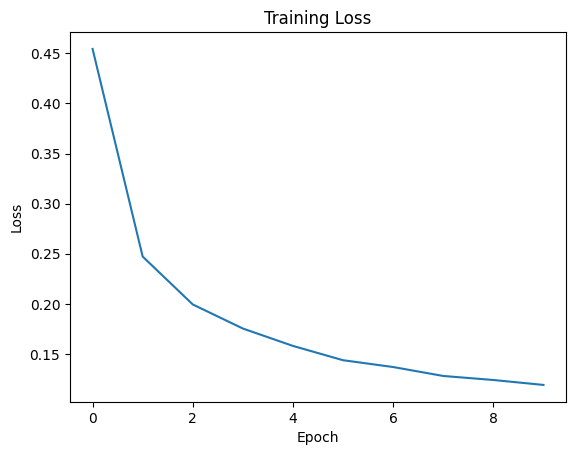

In [19]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# 3. 클래스 기반 Model

## 3.1. 모델 정의

In [23]:
import torch.nn as nn
import torch.nn.functional as F

class MnistNet(nn.Module) :
    def __init__(self) : # 신경모델망 생성자
        super().__init__()
        self.fc1 = nn.Linear(28*28,256)   # 입력특성 4개
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,10)   # 출력 클래스 3개
        
    def forward(self, x) :  # 순방향 학습
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
    

In [24]:
model = MnistNet().to(device)

# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3.2. 모델 학습

In [25]:
# 9. 학습 Loop
num_epochs = 10
loss_history = []

for epoch in range(num_epochs) :
    
    model.train() # 학숩
    total_loss = 0
    
    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    epoch_loss = total_loss / len(train_loader) 
    loss_history.append(epoch_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], loss: {epoch_loss:.4f}")

Epoch [1/10], loss: 0.2771
Epoch [2/10], loss: 0.1064
Epoch [3/10], loss: 0.0695
Epoch [4/10], loss: 0.0510
Epoch [5/10], loss: 0.0383
Epoch [6/10], loss: 0.0306
Epoch [7/10], loss: 0.0245
Epoch [8/10], loss: 0.0202
Epoch [9/10], loss: 0.0164
Epoch [10/10], loss: 0.0168


## 3.3. 학습결과 평가

In [26]:
# 10. 평가
model.eval()

correct = 0
total = 0

with torch.no_grad() :
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)
        
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted==y).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy : {accuracy:.2f}%")

Test Accuracy : 97.92%


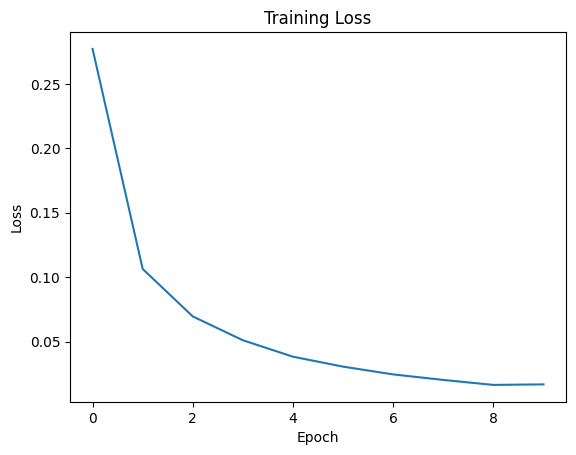

In [27]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()